In [29]:
import torch
torch.set_float32_matmul_precision("high")
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import matplotlib.pyplot as plt
import shapiq 
import src

[No output generated]

### load model

In [30]:
from transformers import AutoProcessor, AutoModel

model = AutoModel.from_pretrained("google/siglip-base-patch16-224")
model.to("cuda")
processor = AutoProcessor.from_pretrained("google/siglip-base-patch16-224")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


### load data

In [31]:
input_text = "black dog next to a yellow hydrant"
# input_image = Image.open("assets/dog_and_hydrant.png")
input_image = Image.open("assets/dog_and_hydrant.png").convert("RGB")


[No output generated]

### define game

In [32]:
from ImputerFactory import ImageImputerFactory
from Game.game_huggingface import VisionLanguageGame

factory = ImageImputerFactory()
imputer = factory.build(model, processor, input_image, input_text)

game = VisionLanguageGame(imputer, batch_size=64)
n_players_image = game.n_players_image
n_players_text = game.n_players_text

[No output generated]

### define approximator

In [33]:
# OOM resolved via chunked ridge regression (ImputerFactory/regression.py).
# max_order=2 is now safe — the chunked accumulator takes ~3.5 GiB
# instead of the original 24+ GiB full regression matrix.
fixlip = src.fixlip.FIxLIP(
    n_players_image=n_players_image,
    n_players_text=n_players_text, 
    max_order=2,
    p=0.5, # weight
    mode="banzhaf",
    random_state=0
)

[No output generated]

In [16]:
# Increase batch size for faster evaluation.
game._batch_size = 128

### compute explanation

In [34]:
import time, psutil, os as _os
import importlib

# Use chunked ridge regression (flash-attention-style tiling) to avoid
# materialising the full N×P regression matrix (24+ GiB at this budget).
from ImputerFactory.regression import crossmodal_approximation

proc = psutil.Process(_os.getpid())
print(f"RAM: {proc.memory_info().rss / 1024**3:.2f} GB", flush=True)

t0 = time.time()
src.utils.set_seed(0)
interaction_values = crossmodal_approximation(
    fixlip, game, budget=2**14, chunk_size=5000, time_game=True,
)

t1 = time.time()
print(f"Done in {t1-t0:.1f}s", flush=True)
print(f"RAM after: {proc.memory_info().rss / 1024**3:.2f} GB", flush=True)
print(f"n_interactions: {len(interaction_values)}", flush=True)
print(interaction_values, flush=True)

RAM: 1.20 GB


Game evaluation: 3.5s


Done in 36.0s


RAM after: 1.34 GB


n_interactions: 21529


InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=True, estimation_budget=16384,
    n_players=207, baseline_value=0.04021671910541392,
    Top 10 interactions:
        (127, 197): 0.8140112122873998
        (128, 197): 0.7915205779581633
        (142, 197): 0.5621649361085983
        (196, 202): 0.4722989683828341
        (196, 201): 0.4722989683828334
        (201, 204): 0.43837457212137465
        (201,): 0.4383743123350979
        (127, 198): 0.43478278508703816
        (128, 198): 0.4073773638101332
        (199, 206): -0.48004995471106354
)


In [18]:
# Larger budget (2^16 = 65536) — chunked aggregation keeps memory safe.
from ImputerFactory.regression import crossmodal_approximation
import time

src.utils.set_seed(0)
t0 = time.time()
interaction_values = crossmodal_approximation(
    fixlip, game, budget=2**16, chunk_size=10000, time_game=True,
)
t1 = time.time()
print(f"Done in {t1-t0:.1f}s", flush=True)
print(f"n_interactions: {len(interaction_values)}", flush=True)

Game evaluation: 6.1s
Done in 163.7s
n_interactions: 21529


### visualize explanation

In [19]:
# SigLIP: decode text tokens from the processor's tokenizer
input_ids = game.inputs['input_ids'][0]
tokens = game.processor.tokenizer.convert_ids_to_tokens(input_ids)
# SentencePiece: strip space prefix '▁', keep empty tokens as padding placeholders
text_tokens = [
    t.replace('▁', '') for t, id_ in zip(tokens, input_ids)
    if id_.item() not in (0, 1)
][:game.n_players_text]
assert len(text_tokens) == game.n_players_text

# Denormalize image
input_image_processed = game.inputs['pixel_values'].squeeze(0)
input_image_denormalized = src.utils.denormalize(
    input_image_processed,
    game.processor.image_processor.image_mean,
    game.processor.image_processor.image_std,
).permute(1, 2, 0).numpy()

print("text tokens:", text_tokens)

text tokens: ['black', 'dog', 'next', 'to', '', 'a', 'yellow', '', 'hydr', 'an', 't']


### FIxLIP

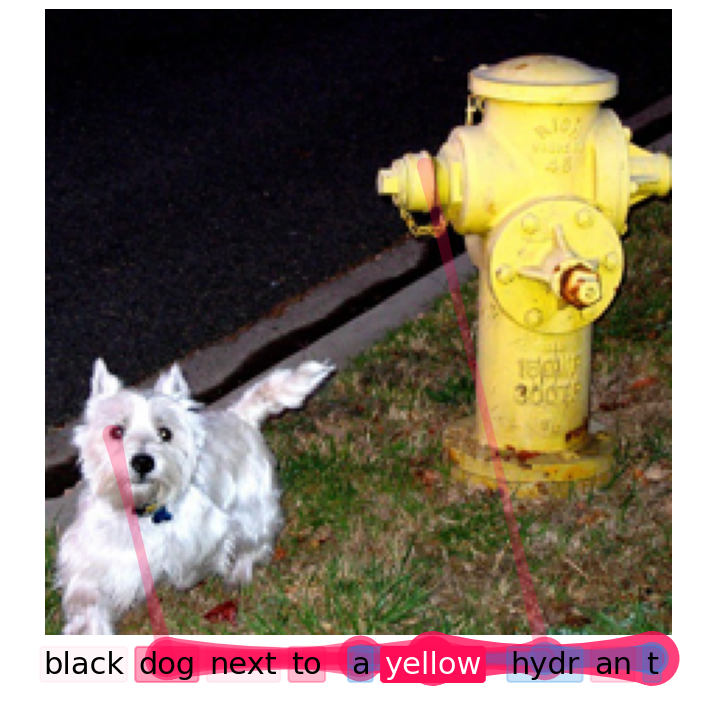

In [24]:
import matplotlib.pyplot as plt

src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(n_players_image)),
    iv=interaction_values,
    plot_interactions=True,
    top_k=14,
    normalize_jointly=True,
    figsize=(7, 7),
    fontsize=22,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=False,
)
plt.tight_layout(pad=0.15)

<string>:12: UserWarning: Index FWBII is not a valid index as defined in {'FBII', 'SV', 'FSII', 'EC', 'CHII', 'BGV', 'CHGV', 'SII', 'ELC', 'JointSV', 'EGV', 'k-SII', 'IGV', 'STII', 'Moebius', 'Co-Moebius', 'BII', 'kADD-SHAP', 'SGV', 'BV'}. This might lead to unexpected behavior.


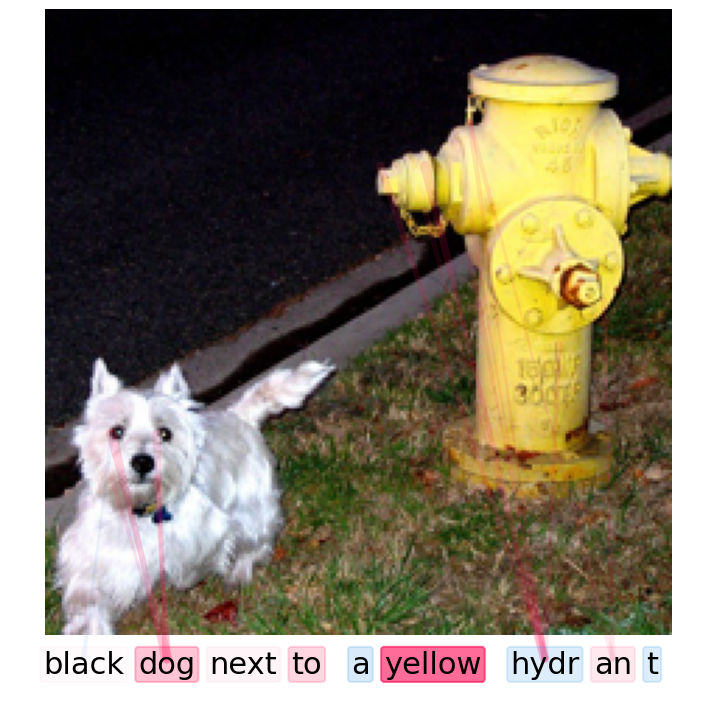

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# SigLIP has 207 players (196 image + 11 text).  The raw top-14 pair
# interactions are dominated by text-text pairs which draw lines within
# the text region only, making it look like coordinate mapping is broken.
#
# Fix: zero out image-image and text-text pair values so the connection
# lines show only crossmodal (image↔text) interactions.
n_img = n_players_image
n_txt = interaction_values.n_players - n_img
# InteractionValues has no .copy(); create a new object with the same structure.
iv_filtered = shapiq.InteractionValues(
    values=interaction_values.values.copy(),
    interaction_lookup=interaction_values.interaction_lookup,
    baseline_value=interaction_values.baseline_value,
    n_players=interaction_values.n_players,
    index=interaction_values.index,
    max_order=interaction_values.max_order,
    min_order=interaction_values.min_order,
    estimated=interaction_values.estimated,
    estimation_budget=interaction_values.estimation_budget,
)

for interaction in iv_filtered.interaction_lookup:
    if len(interaction) == 2:
        p0, p1 = interaction
        is_p0_img = p0 < n_img
        is_p1_img = p1 < n_img
        if is_p0_img == is_p1_img:
            # image-image or text-text pair → suppress
            idx = iv_filtered.interaction_lookup[interaction]
            iv_filtered.values[idx] = 0.0

src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(n_img)),
    iv=iv_filtered,
    plot_interactions=True,
    top_k=min(14, n_img * n_txt),  # cap at number of crossmodal pairs
    normalize_jointly=True,
    figsize=(7, 7),
    fontsize=22,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=False,
    max_value=4,
)
plt.tight_layout(pad=0.15)